# 01 - Message passing from scratch

Almost every GNN is an instance of one simple template, the **Message-Passing Neural
Network (MPNN)**. For each node, in each layer:

1. **Message** - every neighbour sends its current vector.
2. **Aggregate** - collect the neighbour messages with a *permutation-invariant* op
   (mean / sum / max - order can't matter, neighbours have no canonical order).
3. **Update** - combine the aggregate with the node's own vector to get its new vector.

Stack `k` layers and each node has "seen" everything within `k` hops. That's it.
Everything else (GCN, SAGE, GAT, GIN...) is a different choice of *message*,
*aggregate*, and *update*. Let's build one with no library magic and prove it beats
a plain MLP.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## A dataset only a graph model can solve

`make_neighbor_aggregation_regression(lambda)` builds a target with two parts:

$$ y_i = \underbrace{1.5\,x_{i,0} - 1.0\,x_{i,1}}_{\text{own features}}
   \; + \; \lambda \cdot \underbrace{(1.2\,\bar{x}_{0} - 0.8\,\bar{x}_{1})}_{\text{mean of neighbours}}
   \; + \; \text{noise} $$

where $\bar{x}$ is the **average of a node's neighbours' features**. The knob `lambda`
controls how much of the answer lives in the graph:

- `lambda = 0`: the target depends only on a node's *own* features -> an MLP is already optimal.
- `lambda > 0`: part of the answer is the neighbour average, which a node **cannot see by
  itself**. Only a model that reads edges can recover it.

In [2]:
data, gt = G.make_neighbor_aggregation_regression(structure_weight=2.0, seed=1)
print(data)
gt.summary()

Data(x=[800, 8], edge_index=[2, 4800], y=[800, 1], train_mask=[800], val_mask=[800], test_mask=[800])


,value
task,node_regression
description,y = own-feature effect + lambda * neighbour-me...
n_features,8
own_feature_effect,"x0:+1.50, x1:-1.00"
neighbor_mean_effect,"x2:+1.20, x3:-0.80"
structure_weight (lambda),2.0
n_nodes,800
noise_features,"[x4, x5, x6, x7]"


## One message-passing layer, by hand

The core operation is "mean of each node's neighbours". With a symmetric `edge_index`
that's a one-liner with `index_add_`. Watch how a node's value after one layer mixes
in its neighbours - and after two layers, its neighbours' neighbours.

In [3]:
def neighbor_mean(h, edge_index):
    src, dst = edge_index
    agg = torch.zeros_like(h)
    agg.index_add_(0, dst, h[src])                       # sum neighbour vectors
    deg = torch.zeros(h.size(0)).index_add_(0, dst, torch.ones(dst.size(0)))
    return agg / deg.clamp_min(1).unsqueeze(1)           # -> mean

# Receptive field demo: put a single "1" on node 0, watch it spread layer by layer.
signal = torch.zeros(data.num_nodes, 1); signal[0] = 1.0
reached = [(signal > 0).sum().item()]
h = signal
for _ in range(4):
    h = (neighbor_mean(h, data.edge_index) > 0).float() + h   # keep anything reached
    reached.append((h > 0).sum().item())
print("nodes reachable within k hops of node 0:", reached)
print("-> stacking layers = a larger receptive field.")

nodes reachable within k hops of node 0: [1, 7, 25, 70, 206]
-> stacking layers = a larger receptive field.


## The from-scratch GNN

`utils/models.py:ScratchGNN` writes the full layer out explicitly:

```python
m_i = mean_{j in N(i)} h_j                 # message + aggregate
h_i = ReLU( W_self @ h_i  +  W_neigh @ m_i )   # update (separate self / neighbour weights!)
```

The *separate* `W_self` and `W_neigh` matter: they let the model keep a node's own
signal **and** read the neighbour average - exactly the two ingredients of our target.
Let's train it against an MLP at `lambda = 2`.

In [4]:
T.set_seed(0)
mlp     = M.MLP(data.num_features, 32, 1)
scratch = M.ScratchGNN(data.num_features, 32, 1, n_layers=2)

r_mlp = T.train_node(mlp,     data, task="regression", epochs=200)
r_gnn = T.train_node(scratch, data, task="regression", epochs=200)
print(f"MLP (ignores edges) test R2 = {r_mlp['test_metric']:.3f}")
print(f"ScratchGNN          test R2 = {r_gnn['test_metric']:.3f}")

MLP (ignores edges) test R2 = 0.638
ScratchGNN          test R2 = 0.962


## The key experiment: sweep lambda

Now turn the knob. As `lambda` grows, more of the answer hides in the graph. We expect the
MLP to **decay** (it can never see neighbours) while the GNN **holds**. We also throw in
PyG's `SAGEConv`, which uses the same separate-self-and-neighbour idea (notebook 03).

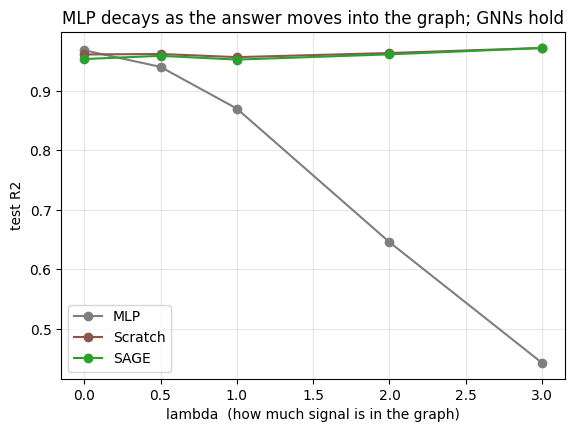

,MLP,Scratch,SAGE
lambda=0.0,0.969,0.961,0.954
lambda=0.5,0.941,0.962,0.959
lambda=1.0,0.870,0.957,0.953
lambda=2.0,0.646,0.964,0.962
lambda=3.0,0.443,0.972,0.972


In [5]:
lambdas = [0.0, 0.5, 1.0, 2.0, 3.0]
series = {"MLP": [], "Scratch": [], "SAGE": []}
for lam in lambdas:
    d, _ = G.make_neighbor_aggregation_regression(structure_weight=lam, seed=1)
    T.set_seed(0)
    series["MLP"].append(    T.train_node(M.MLP(d.num_features,32,1), d, task="regression", epochs=200)["test_metric"])
    series["Scratch"].append(T.train_node(M.ScratchGNN(d.num_features,32,1,n_layers=2), d, task="regression", epochs=200)["test_metric"])
    series["SAGE"].append(   T.train_node(M.GNN(d.num_features,32,1,conv="sage",n_layers=2,dropout=0.0), d, task="regression", epochs=200)["test_metric"])

P.plot_sweep(lambdas, series, xlabel="lambda  (how much signal is in the graph)",
             ylabel="test R2", title="MLP decays as the answer moves into the graph; GNNs hold")
plt.show()
pd.DataFrame(series, index=[f"lambda={l}" for l in lambdas]).round(3)

## Takeaway

- A GNN = **message -> aggregate -> update**, stacked. The whole field is variations on
  those three choices.
- The graph buys you something **exactly when the target depends on relationships**
  (here, the neighbour average). At `lambda = 0` the GNN gives you *nothing* over an MLP -
  the first hint of *when not* to use one (notebook 10 makes this prescription explicit).
- Keeping a **separate self-weight** lets a GNN read neighbours without forgetting the
  node itself. The next notebook shows what happens (GCN) when you *don't*.